In [1]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

In [4]:
gmm_cache = build_gmm_cache(input_dir = os.path.join(data_workspace, "mat_files/synth"), processing_func = LogMapping(c = 1000.0))

Found 1345 .mat files


Fitting GMMs: 100%|██████████| 1345/1345 [02:51<00:00,  7.86it/s]


# Bright spot

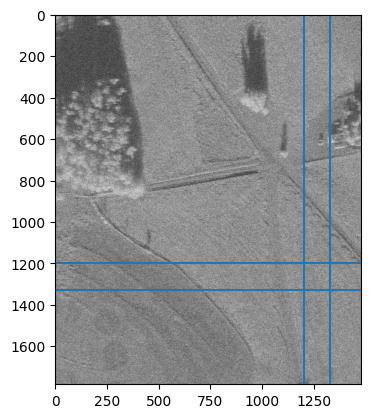

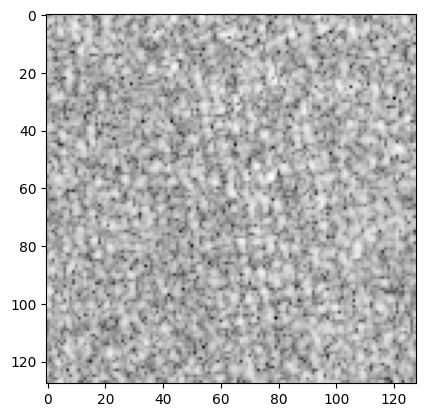

In [4]:
xk = 1200
yk = 1200

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [5]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
meas_ds_path = [meas_ds.samples[i][0] for i in range(len(meas_ds))]

In [7]:
clutter_cache1 = {file: (os.path.join(clutter_dir, 'HB06158'), 1200, 1200) for file in meas_ds_path}

In [8]:
meas_ds_s2_1 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache1), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

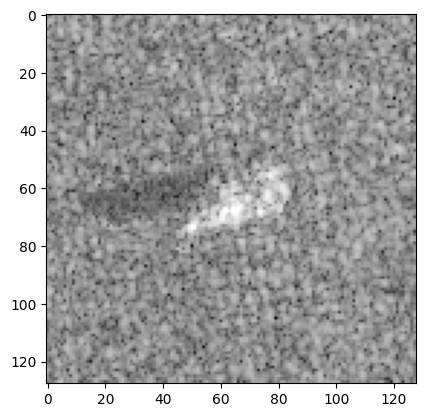

In [10]:
plt.imshow(meas_ds_s2_1[0][0][0], cmap = "grey")
plt.show()

In [11]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

In [12]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds_s2_1, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 10
Test Accuracy: 0.8639
Evaluating Run 1: seed 42
Test Accuracy: 0.8550
Evaluating Run 2: seed 100
Test Accuracy: 0.8357
Evaluating Run 3: seed 123
Test Accuracy: 0.8238
Evaluating Run 4: seed 666
Test Accuracy: 0.8015
Evaluating Run 5: seed 777
Test Accuracy: 0.8461
Evaluating Run 6: seed 849
Test Accuracy: 0.8736
Evaluating Run 7: seed 1000
Test Accuracy: 0.8364
Evaluating Run 8: seed 1111
Test Accuracy: 0.8602
Evaluating Run 9: seed 1234
Test Accuracy: 0.8996


In [13]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 80.1487
Max: 89.9628
Avg, Std: 84.9591, 2.6052


In [9]:
combined_ds1 = ConcatDataset([synth_ds, meas_ds_s2_1])
combined_loader1 = DataLoader(combined_ds1, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

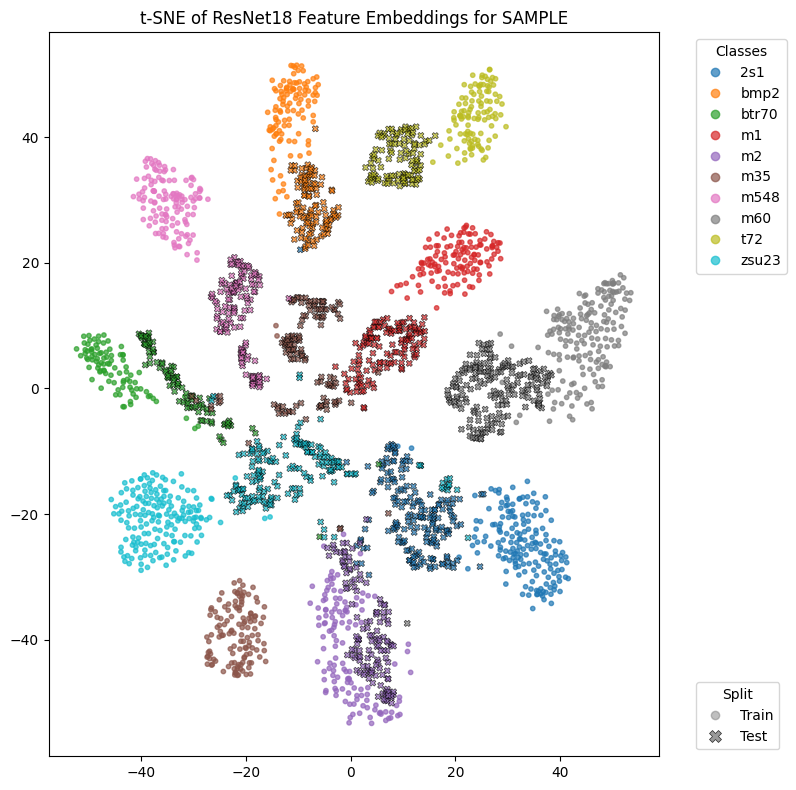

In [10]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run7_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in tqdm(combined_loader1, leave = False):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(synth_ds), 0],
    features_2d[:len(synth_ds), 1],
    c=labels_list[:len(synth_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(synth_ds):, 0],
    features_2d[len(synth_ds):, 1],
    c=labels_list[len(synth_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

# Dark spot

In [11]:
clutter_cache2 = {file: (os.path.join(clutter_dir, 'HB06158'), 100, 100) for file in meas_ds_path}

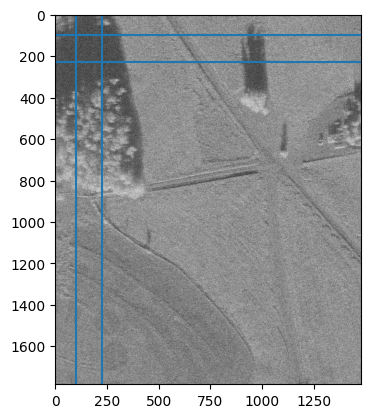

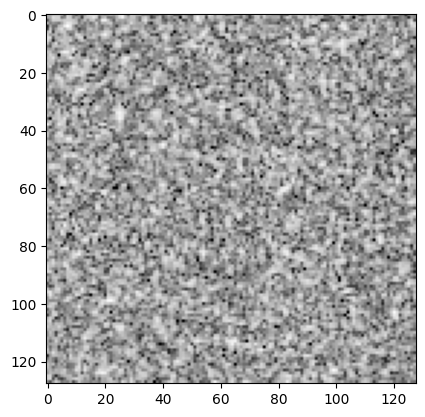

In [12]:
xk = 100
yk = 100

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [13]:
meas_ds_s2_2 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache2), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

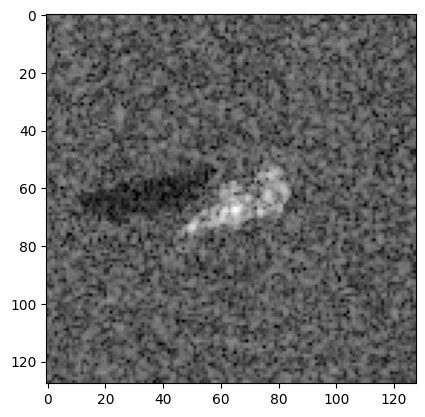

In [14]:
plt.imshow(meas_ds_s2_2[0][0][0], cmap = "grey")
plt.show()

In [15]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

In [16]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds_s2_2, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 10
Test Accuracy: 0.9212
Evaluating Run 1: seed 42
Test Accuracy: 0.9160
Evaluating Run 2: seed 100
Test Accuracy: 0.9115
Evaluating Run 3: seed 123
Test Accuracy: 0.8959
Evaluating Run 4: seed 666
Test Accuracy: 0.8803
Evaluating Run 5: seed 777
Test Accuracy: 0.8840
Evaluating Run 6: seed 849
Test Accuracy: 0.9123
Evaluating Run 7: seed 1000
Test Accuracy: 0.9041
Evaluating Run 8: seed 1111
Test Accuracy: 0.9167
Evaluating Run 9: seed 1234
Test Accuracy: 0.9093


In [17]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 88.0297
Max: 92.1190
Avg, Std: 90.5130, 1.3297


In [18]:
combined_ds2 = ConcatDataset([synth_ds, meas_ds_s2_2])
combined_loader2 = DataLoader(combined_ds2, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

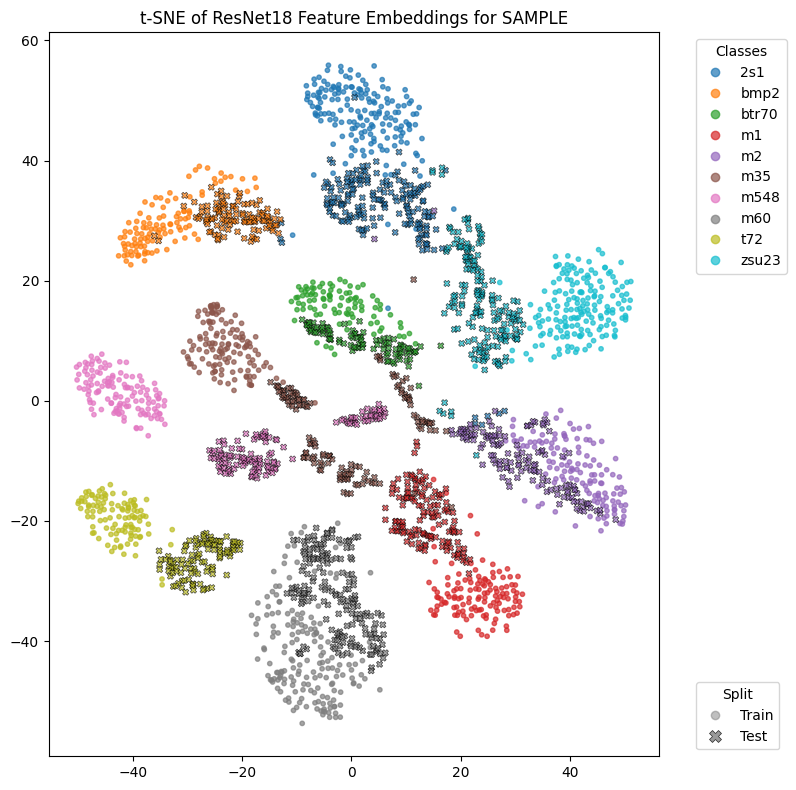

In [19]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run7_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in tqdm(combined_loader2, leave = False):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(synth_ds), 0],
    features_2d[:len(synth_ds), 1],
    c=labels_list[:len(synth_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(synth_ds):, 0],
    features_2d[len(synth_ds):, 1],
    c=labels_list[len(synth_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

# Mixed

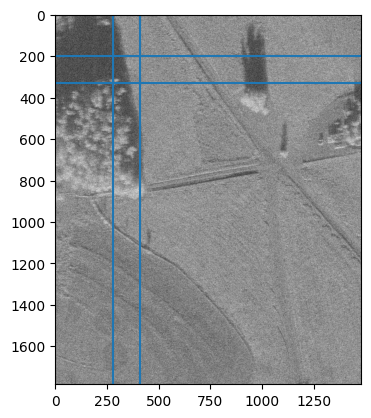

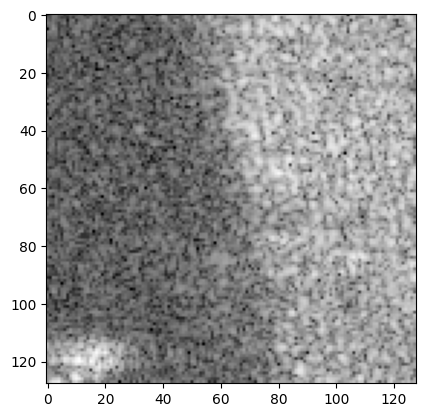

In [20]:
xk = 280
yk = 200

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [21]:
clutter_cache3 = {file: (os.path.join(clutter_dir, 'HB06158'), 200, 280) for file in meas_ds_path}

In [22]:
meas_ds_s2_3 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

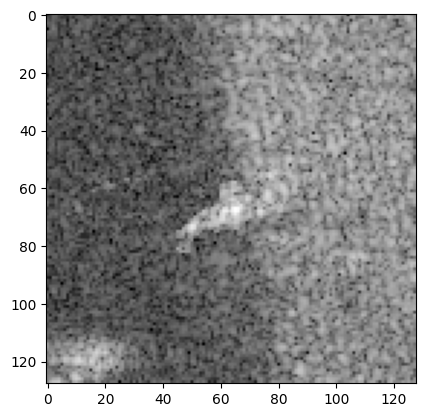

In [23]:
plt.imshow(meas_ds_s2_3[0][0][0], cmap = "grey")
plt.show()

In [24]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds_s2_3, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 10
Test Accuracy: 0.6833
Evaluating Run 1: seed 42
Test Accuracy: 0.7197
Evaluating Run 2: seed 100
Test Accuracy: 0.6535
Evaluating Run 3: seed 123
Test Accuracy: 0.6461
Evaluating Run 4: seed 666
Test Accuracy: 0.5740
Evaluating Run 5: seed 777
Test Accuracy: 0.6431
Evaluating Run 6: seed 849
Test Accuracy: 0.6416
Evaluating Run 7: seed 1000
Test Accuracy: 0.6409
Evaluating Run 8: seed 1111
Test Accuracy: 0.6164
Evaluating Run 9: seed 1234
Test Accuracy: 0.6617


In [25]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 57.3978
Max: 71.9703
Avg, Std: 64.8030, 3.6336


In [26]:
combined_ds3 = ConcatDataset([synth_ds, meas_ds_s2_3])
combined_loader3 = DataLoader(combined_ds3, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

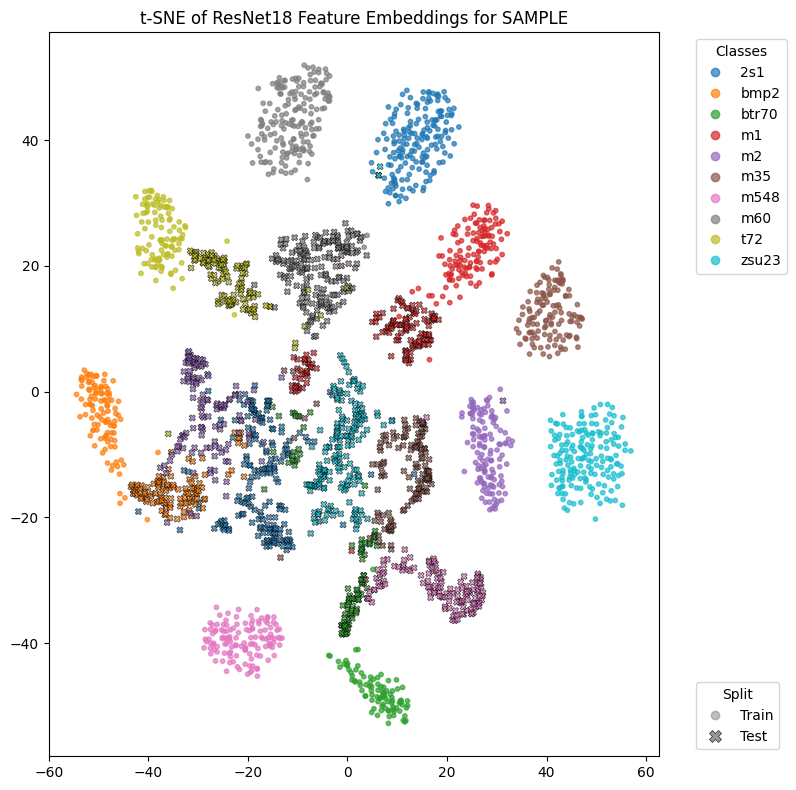

In [27]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run7_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in tqdm(combined_loader3, leave = False):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(synth_ds), 0],
    features_2d[:len(synth_ds), 1],
    c=labels_list[:len(synth_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(synth_ds):, 0],
    features_2d[len(synth_ds):, 1],
    c=labels_list[len(synth_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()